In [38]:
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from gensim.test.utils import common_texts
from gensim.parsing.preprocessing import preprocess_string

from nltk import sent_tokenize

from sklearn.decomposition import PCA

%matplotlib inline

In [10]:
from pysrc.papers.utils import build_corpus, tokenize

In [3]:
from utils.io import load_analyzer, get_review_pmids

In [4]:
reviews = get_review_pmids()

In [7]:
PMID = '28003656'

In [8]:
analyzer = load_analyzer(PMID)

In [28]:
abstracts = list(analyzer.df.abstract.values)

In [29]:
corpus = []

for abstract in abstracts:
    for sent in sent_tokenize(abstract):
        corpus.append(preprocess_string(sent))

In [58]:
model = Word2Vec(corpus, min_count=5)

In [70]:
model.wv.vocab.keys()

dict_keys(['neuroimag', 'studi', 'human', 'social', 'cognit', 'focus', 'brain', 'activ', 'singl', 'subject', 'recent', 'person', 'introduc', 'simultan', 'record', 'signal', 'involv', 'interact', 'carri', 'spectrum', 'modal', 'function', 'magnet', 'reson', 'imag', 'fmri', 'electroencephalographi', 'eeg', 'near', 'develop', 'setup', 'meg', 'commun', 'real', 'time', 'link', 'separ', 'present', 'extend', 'version', 'ad', 'video', 'connect', 'base', 'enabl', 'transmiss', 'stream', 'site', 'wai', 'allow', 'reproduc', 'avail', 'demonstr', 'mediat', 'mirror', 'hand', 'movement', 'pair', 'abl', 'synchron', 'behavior', 'addit', 'captur', 'attach', 'index', 'finger', 'determin', 'averag', 'accuraci', 'inter', 'coher', 'pattern', 'peak', 'sensorimotor', 'area', 'contralater', 'task', 'noninvas', 'neural', 'infer', 'local', 'fluctuat', 'fundament', 'question', 'driven', 'primarili', 'synapt', 'spike', 'critic', 'interpret', 'blood', 'oxygen', 'level', 'depend', 'bold', 'establish', 'visual', 'circu

In [59]:
freq = sorted([(w, model.wv.vocab[w].count) for w in model.wv.vocab],
              key=lambda el: el[1], reverse=True)

In [71]:
words = ['adhd', 'stroke', 'eeg', 'meg', 'fmri', 'visual', 'sensorimotor', 'lfp', 'bold', 'human', 'rat', 'monkei', 
         'mri', 'autism', 'schizophrenia', 'macaqu', 'delta', 'beta', 'theta', 'alpha', 'rtfmri', 'tetraplegia', 
         'alzheim']

In [72]:
X = model[words]
pca = PCA(n_components=2)
result = pca.fit_transform(X)

<ipython-input-72-7fecf15bedc1>:1: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).
  X = model[words]


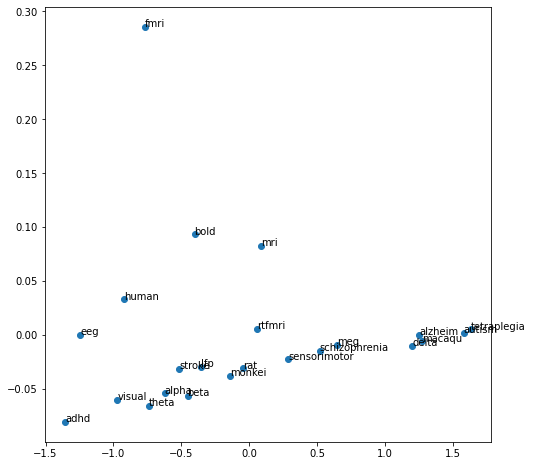

In [73]:
plt.figure(figsize=(8, 8))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

In [86]:
model.wv.most_similar('eeg')

[('subject', 0.9998519420623779),
 ('test', 0.9998408555984497),
 ('combin', 0.9998396039009094),
 ('scan', 0.9998384714126587),
 ('approach', 0.9998359084129333),
 ('method', 0.999830961227417),
 ('appli', 0.9998307824134827),
 ('base', 0.9998302459716797),
 ('review', 0.9998261332511902),
 ('simultan', 0.9998249411582947)]